# 单机多卡并行


## 并行模式
一台机器可以安装多个 GPU，多卡并行就是在一台机器上使用多个 GPU 进行训练。
- 数据并行
- 模型并行
- 通道并行（数据+模型）

## 模型并行（略）
将模型分成 n 块，每个 GPU 拿到一块模型计算前向和反向结果。

## 数据并行
将数据分成 n 块，每个 GPU 拿到完整参数计算一块数据的梯度。
```mermaid
sequenceDiagram
    participant GPU as 副GPU
    participant CPU as 主GPU

    CPU->>GPU: 读取数据块
    CPU->>GPU: 拿到模型参数
    GPU->>GPU: 计算梯度
    GPU->>CPU: 发出梯度
    CPU->>CPU: 更新参数
```


## 实现


In [1]:
%matplotlib inline
import torch
from torch import nn
from torch.nn import functional as F
import util

/root/autodl-tmp/envs/daily_learning/lib/python3.11/site-packages/requests/__init__.py:92: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


### 从零实现


LeNet


In [2]:
scale = 0.01
W1 = torch.randn((20, 1, 3, 3)) * scale
b1 = torch.zeros(20)
W2 = torch.randn((50, 20, 5, 5)) * scale
b2 = torch.zeros(50)
W3 = torch.randn((800, 128)) * scale
b3 = torch.zeros(128)
W4 = torch.randn((128, 10)) * scale
b4 = torch.zeros(10)
params = [W1, b1, W2, b2, W3, b3, W4, b4]

def lenet(X, params):
    # 3x3卷积
    h1_conv = F.conv2d(X, params[0], params[1])
    h1_activation = F.relu(h1_conv)
    h1 = F.avg_pool2d(h1_activation, kernel_size=2, stride=2)
    # 5x5卷积
    h2_conv = F.conv2d(h1, params[2], params[3])
    h2_activation = F.relu(h2_conv)
    h2 = F.avg_pool2d(h2_activation, kernel_size=2, stride=2)
    # 全连接
    h2 = h2.reshape(h2.shape[0], -1)
    h3_linear = torch.matmul(h2, params[4]) + params[5]
    h3 = F.relu(h3_linear)
    y_hat = torch.matmul(h3, params[6]) + params[7]
    return y_hat

向多个设备分发参数


In [3]:
def get_params(params, device):
    """将参数分发到指定设备"""
    # 同设备 to() 方法不操作，clone() 确保复制
    new_params = [p.clone().to(device) for p in params]
    # 设置 requires_grad 为 True
    [p.requires_grad_() for p in new_params]
    return new_params

new_params = get_params(params, util.try_gpu())
print('b1 weight', new_params[1].data)  # 输出参数值
print('b1 grad', new_params[1].grad)  # 输出参数梯度

b1 weight tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       device='cuda:0')
b1 grad None


#### All-reduce

收集每个 GPU 的梯度，求和后再分发回每个 GPU。


In [4]:
def allreduce(data: list[torch.Tensor]):
    # 将每个 GPU 的梯度加到主 GPU 上
    for i in range(1, len(data)):
        # [:] 是完整切片，表示原地赋值
        data[0][:] += data[i].to(data[0].device)
    # 将主 GPU 的梯度分发回每个 GPU
    for i in range(1, len(data)):
        data[i][:] = data[0].to(data[i].device)

data = [torch.ones((2, 3), device=util.try_gpu(i)) for i in range(2)]
print("Before allreduce:\n", '\n'.join([str(d.data) for d in data]))
allreduce(data)
print("After allreduce:\n", '\n'.join([str(d.data) for d in data]))

Before allreduce:
 tensor([[1., 1., 1.],
        [1., 1., 1.]], device='cuda:0')
tensor([[1., 1., 1.],
        [1., 1., 1.]], device='cuda:1')
After allreduce:
 tensor([[2., 2., 2.],
        [2., 2., 2.]], device='cuda:0')
tensor([[2., 2., 2.],
        [2., 2., 2.]], device='cuda:1')


将小批量数据均匀地分布在多个 GPU 上


In [5]:
data = torch.arange(12).reshape(4, 3) # (batch, features)
devices = util.try_all_gpus()
# 将数据分发到多个 GPU 上
def distribute(data, devices):
    # tensor.split() 按指定维度、大小分割张量，返回元组
    return [d.to(devices[i]) for i, d in enumerate(data.split(data.shape[0]//len(devices), dim=0))]
split_data = distribute(data, devices)
print("Split data:\n", '\n'.join([str(d.data) for d in split_data]))

# torch 里的工具
scatter = nn.parallel.scatter(data, devices, dim=0)
print('torch scatter:\n', '\n'.join([str(d.data) for d in scatter]))

Split data:
 tensor([[0, 1, 2]], device='cuda:0')
tensor([[3, 4, 5]], device='cuda:1')
tensor([[6, 7, 8]], device='cuda:2')
tensor([[ 9, 10, 11]], device='cuda:3')
torch scatter:
 tensor([[0, 1, 2]], device='cuda:0')
tensor([[3, 4, 5]], device='cuda:1')
tensor([[6, 7, 8]], device='cuda:2')
tensor([[ 9, 10, 11]], device='cuda:3')


In [6]:
def split_batch(X, y, devices):
    """将小批量数据均匀地分布在多个 GPU 上"""
    assert X.shape[0] == y.shape[0], "X 和 y 的样本数必须相同"
    # 按 batch 维度拆分
    X_split = distribute(X, devices)
    y_split = distribute(y, devices)
    return X_split, y_split

在小批量上实现并行训练


In [7]:
def train_batch(X: torch.Tensor,
                y: torch.Tensor,
                device_params: list[list[torch.Tensor]],
                devices: list[torch.device],
                lr: float,
                loss: nn.Module):
    """在小批量上实现并行训练"""
    assert len(device_params) == len(devices), "设备参数和设备数量不匹配"
    # 将小批量数据均匀地分布在多个 GPU 上
    X_split, y_split = split_batch(X, y, devices)
    # 在每个 GPU 上计算梯度
    ls = [
        loss(
            lenet(X_split[i], device_params[i]),
            y_split[i]
        ) for i in range(len(devices))
    ]
    [l.backward() for l in ls]  # 反向传播
    # 聚合每个 GPU 的梯度
    with torch.no_grad():
        for i in range(len(device_params[0])):
            # c 是设备索引，i 是参数索引
            allreduce([device_params[c][i].grad for c in range(len(devices))])
    # 更新参数
    for params in device_params:
        util.train.sgd(params, lr, batch_size=X.shape[0])


训练


In [8]:
def train(num_gpus, batch_size, lr, num_epochs):
    """训练函数"""
    # 将参数分发到每个 GPU 上
    devices = [util.try_gpu(i) for i in range(num_gpus)]
    device_params = [get_params(params, device) for device in devices]
    # 常规训练流程
    loss = nn.CrossEntropyLoss(reduction='sum') # 使用 sum 计算损失，便于梯度聚合
    train_iter, test_iter = util.data.load_data_fashion_mnist(batch_size)
    animator = util.Animator(xlabel='epoch', ylabel='test acc', xlim=[1, num_epochs])
    timer = util.Timer()
    for epoch in range(num_epochs):
        timer.start()
        for X, y in train_iter:
            train_batch(X, y, device_params, devices, lr, loss)
            # synchronize() 等待所有 GPU 的计算完成，主要为了计算时间
            torch.cuda.synchronize()
        timer.stop()
        animator.add(epoch + 1,
                     (util.train.evaluate_accuracy_gpu(lambda x: lenet(x, device_params[0]),
                                                       test_iter,
                                                       devices[0]),))
    print(f'test acc: {animator.Y[0][-1]:.2f}, {timer.avg():.1f} sec/epoch', f'on {str(devices)}')

单 gpu 上运行


test acc: 0.81, 7.2 sec/epoch on [device(type='cuda', index=0)]


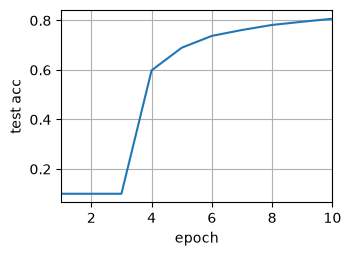

In [9]:
train(num_gpus=1, batch_size=32, lr=0.01, num_epochs=10)

增加为多个 GPU


test acc: 0.68, 10.7 sec/epoch on [device(type='cuda', index=0), device(type='cuda', index=1), device(type='cuda', index=2), device(type='cuda', index=3)]


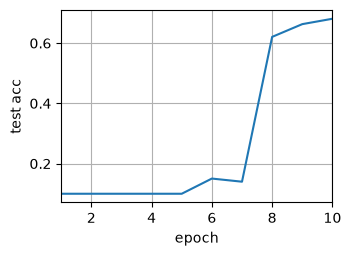

In [10]:
train(num_gpus=len(devices), batch_size=32*2, lr=0.01, num_epochs=10)

### 简洁实现


resnet-18


In [11]:
def resnet18(num_classes, in_channels=1):
    """使用了更小的卷积核、步长和填充，而且删除了最大汇聚层"""
    net = nn.Sequential(
        nn.Conv2d(in_channels, 64, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU()
    )
    net.add_module("resnet_block1", util.model.resnet_block(64, 64, 2, first_block=True))
    net.add_module("resnet_block2", util.model.resnet_block(64, 128, 2))
    net.add_module("resnet_block3", util.model.resnet_block(128, 256, 2))
    net.add_module("resnet_block4", util.model.resnet_block(256, 512, 2))
    net.add_module("global_avg_pool", nn.AdaptiveAvgPool2d((1,1)))
    net.add_module("fc", nn.Sequential(nn.Flatten(),
                                       nn.Linear(512, num_classes)))
    return net

训练

In [12]:
def train_simp(net, num_gpus, batch_size, lr, num_epochs):
    # 初始化模型参数
    def init_weights(m):
        if type(m) in [nn.Linear, nn.Conv2d]:
            nn.init.xavier_uniform_(m.weight)
    net.apply(init_weights)
    # 将模型分发到多个 GPU 上
    devices = [util.try_gpu(i) for i in range(num_gpus)]
    # DataParallel 指定模型和设备，返回新的模型（重新定义 forward）
    # 自动将模型复制到每个 GPU 上，以后输入数据也会被分发到每个 GPU 上
    net = nn.DataParallel(net, device_ids=devices).to(devices[0])
    # 正常训练流程
    loss = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(net.parameters(), lr=lr)
    train_iter, test_iter = util.data.load_data_fashion_mnist(batch_size)
    animator = util.Animator(xlabel='epoch', ylabel='test acc', xlim=[1, num_epochs])
    timer = util.Timer()
    for epoch in range(num_epochs):
        net.train()
        timer.start()
        for X, y in train_iter:
            X, y = X.to(devices[0]), y.to(devices[0])
            optimizer.zero_grad()
            l = loss(net(X), y)
            l.backward()
            optimizer.step()
        timer.stop()
        animator.add(epoch + 1,
                     (util.train.evaluate_accuracy_gpu(net, test_iter, devices[0]),))
    print(f'test acc: {animator.Y[0][-1]:.2f}, {timer.avg():.1f} sec/epoch', f'on {str(devices)}')

单gpu

test acc: 0.92, 26.0 sec/epoch on [device(type='cuda', index=0)]


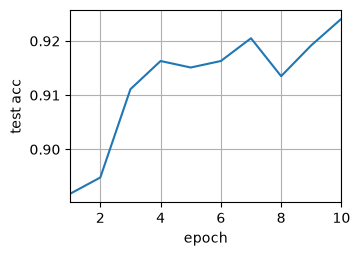

In [13]:
net = resnet18(10)
train_simp(net, num_gpus=1, batch_size=32, lr=0.01, num_epochs=10)

多gpu

test acc: 0.92, 60.4 sec/epoch on [device(type='cuda', index=0), device(type='cuda', index=1), device(type='cuda', index=2), device(type='cuda', index=3)]


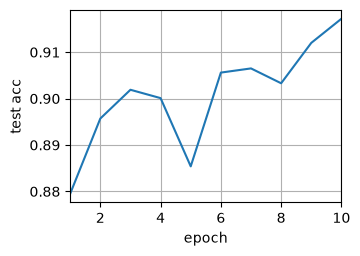

In [14]:
net = resnet18(10)
train_simp(net, num_gpus=len(devices), batch_size=32*2, lr=0.01, num_epochs=10)